In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, gc, warnings
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from contextlib import redirect_stdout
from scipy.stats import zscore
from adjustText import adjust_text
from matplotlib.patches import Patch
import scipy.cluster.hierarchy as shc
from sklearn.metrics import silhouette_score

In [2]:
resample_res = pd.read_csv('../data/track2_resample_results.csv')

In [3]:
resample_res.head()

,cyt,kmer,baseline_coef,coef_mean,coef_lower,coef_upper,topn_stability,cv_stability,perc_neg,perc_pos,sign_stability,mean_scale,composite_score
0,IL12P40,ATTTAGGT,0.375985,0.379121,0.273571,0.474051,1.0,0.879424,0.0,1.0,1.0,0.921878,0.927654
1,IFNB,AGAAGGTC,-0.447930,-0.456400,-0.597520,-0.314388,1.0,0.859891,1.0,0.0,1.0,1.000000,0.915935
2,IL2,GCCGGAGC,-0.282042,-0.286229,-0.372277,-0.190222,1.0,0.859534,1.0,0.0,1.0,0.529161,0.915721
3,TGFA,AGAAGGTC,-0.425474,-0.430660,-0.578469,-0.285429,1.0,0.854496,1.0,0.0,1.0,0.798476,0.912697
4,IL17F,AGAAGGTC,-0.434258,-0.438913,-0.592427,-0.300978,1.0,0.853802,1.0,0.0,1.0,0.677852,0.912281


In [4]:
resample_res.describe()

,baseline_coef,coef_mean,coef_lower,coef_upper,topn_stability,cv_stability,perc_neg,perc_pos,sign_stability,mean_scale,composite_score
count,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000,17292.000000
mean,-0.000771,-0.000743,-0.154446,0.152987,0.381679,0.433673,0.505869,0.494131,0.787039,0.182393,0.575020
std,0.105037,0.104527,0.130365,0.134758,0.261433,0.200203,0.325457,0.325457,0.153493,0.166715,0.181208
min,-0.692184,-0.650941,-1.181284,-0.314388,0.000000,0.000055,0.000000,0.000000,0.500000,0.000000,0.200151
25%,-0.061779,-0.061122,-0.211188,0.070146,0.160000,0.282597,0.205000,0.189000,0.653000,0.063066,0.431090
50%,-0.001914,-0.001905,-0.136185,0.131092,0.330000,0.460581,0.514000,0.486000,0.804000,0.138875,0.597588
75%,0.057184,0.057222,-0.071858,0.209298,0.565000,0.594935,0.811000,0.795000,0.929000,0.249318,0.728526
max,0.606671,0.647057,0.273571,1.293156,1.000000,0.879424,1.000000,1.000000,1.000000,1.000000,0.927654


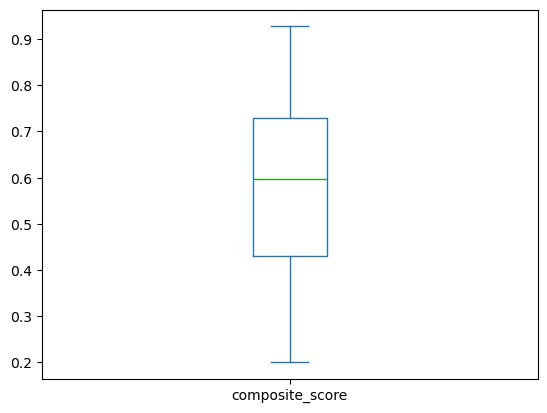

In [5]:
resample_res.composite_score.plot.box();

In [6]:
# number of kmers with 70% composite score
resample_res.query('composite_score >= 0.75').kmer.nunique()

260

In [7]:
resample_res.filter(regex='coef').corr('spearman')

,baseline_coef,coef_mean,coef_lower,coef_upper
baseline_coef,1.000000,0.997058,0.828433,0.823727
coef_mean,0.997058,1.000000,0.831454,0.825718
coef_lower,0.828433,0.831454,1.000000,0.459912
coef_upper,0.823727,0.825718,0.459912,1.000000


In [8]:
resample_res.filter(regex='sign|cv|stab|scale').corr('spearman')

,topn_stability,cv_stability,sign_stability,mean_scale
topn_stability,1.000000,0.679560,0.679076,0.854089
cv_stability,0.679560,1.000000,0.998766,0.882462
sign_stability,0.679076,0.998766,1.000000,0.881611
mean_scale,0.854089,0.882462,0.881611,1.000000


In [9]:
# get correlation for simulated and baseline coefficients
simul_actual_coef = resample_res.filter(regex='coef_mean|baseline').corr().values[0, 1]

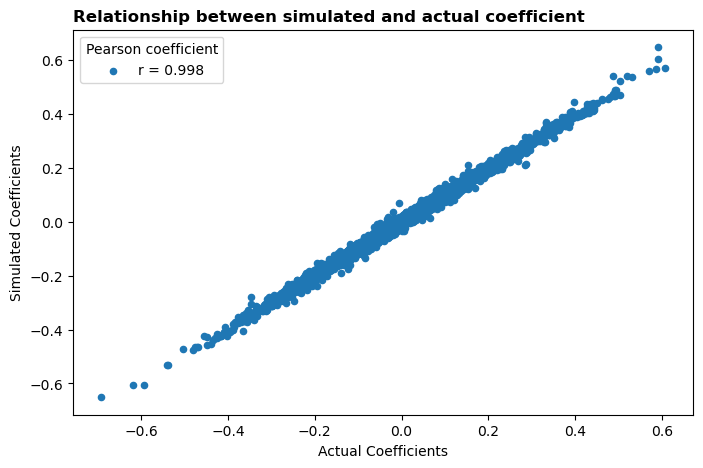

In [11]:
resample_res.plot.scatter(x='baseline_coef', y='coef_mean',figsize=(8,5), label=f'r = {simul_actual_coef:.3f}')
plt.title('Relationship between simulated and actual coefficient', loc='left', fontdict={'fontsize':12, 'fontweight':'bold'})
plt.ylabel('Simulated Coefficients')
plt.xlabel('Actual Coefficients')
plt.legend(title='Pearson coefficient')
plt.savefig('imgs/simulated_vs_actual_coef.png', dpi=300, bbox_inches='tight')

In [12]:
def visualise_top_by_stability(df, group, cutoff=0.5, n=20):
    groups = ['kmer', 'cyt']
    groups.remove(group)  # the other group

    # Filter and aggregate
    res = df.query(f'composite_score >= {cutoff}').groupby(group).agg({
        'cv_stability': 'mean', f'{groups[0]}': 'nunique',
        'sign_stability': 'mean', 'composite_score': 'mean'
    }).reset_index()

    # Create color palette based on composite score
    norm_scores = (res['composite_score'] - res['composite_score'].min()) / (res['composite_score'].max() - res['composite_score'].min())
    palette = sns.color_palette("viridis", as_cmap=True)
    colors = palette(norm_scores)

    # Identify top N groups
    topn_group = res.nlargest(n//2, 'composite_score')
    leastn_group = res.nsmallest(n//2, 'composite_score')
    groups_df = pd.concat([topn_group, leastn_group]).reset_index(drop=True)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(res['sign_stability'], res['cv_stability'], s=res[f'{groups[0]}'] * 2,  # scale size
                        c=colors, alpha=0.7, edgecolor='k')

    # Annotate top N
    texts = []
    for _, row in groups_df.iterrows():
        text = ax.text(row['sign_stability'], row['cv_stability'], str(row[group]), fontsize=8, weight=25, 
                ha='center', va='center', color='k', bbox=dict(facecolor='w', alpha=0.6, boxstyle='round,pad=0.2'))
        texts.append(text)
    
    adjust_text(texts, ax=ax, pull_threshold=20, explode_radius=20, force_text=(1.2, 1.5))
    # Labels and title
    name = {'cyt': 'Cytokine', 'kmer': 'Kmer'}
    ax.set_title(f'Stability Landscape of Kmer-Cytokine Associations ({name.get(group)})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sign Stability')
    ax.set_ylabel('CV Stability')

    plt.tight_layout()


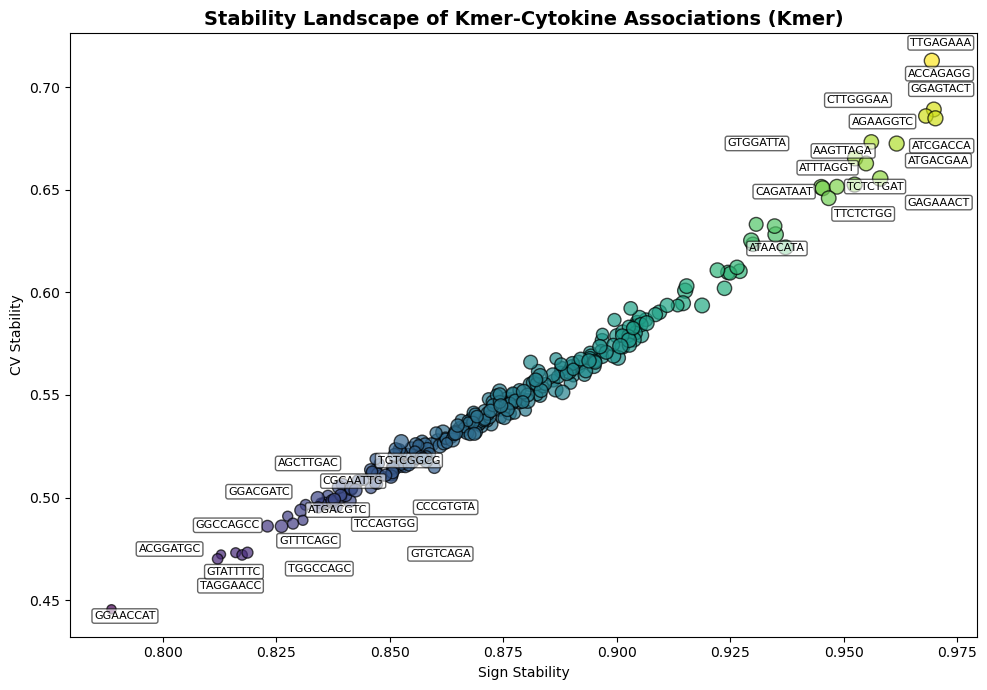

In [13]:
visualise_top_by_stability(resample_res, 'kmer', n=30)
plt.savefig('imgs/kmer_cytokine_association_kmer.png', dpi=400, bbox_inches='tight')

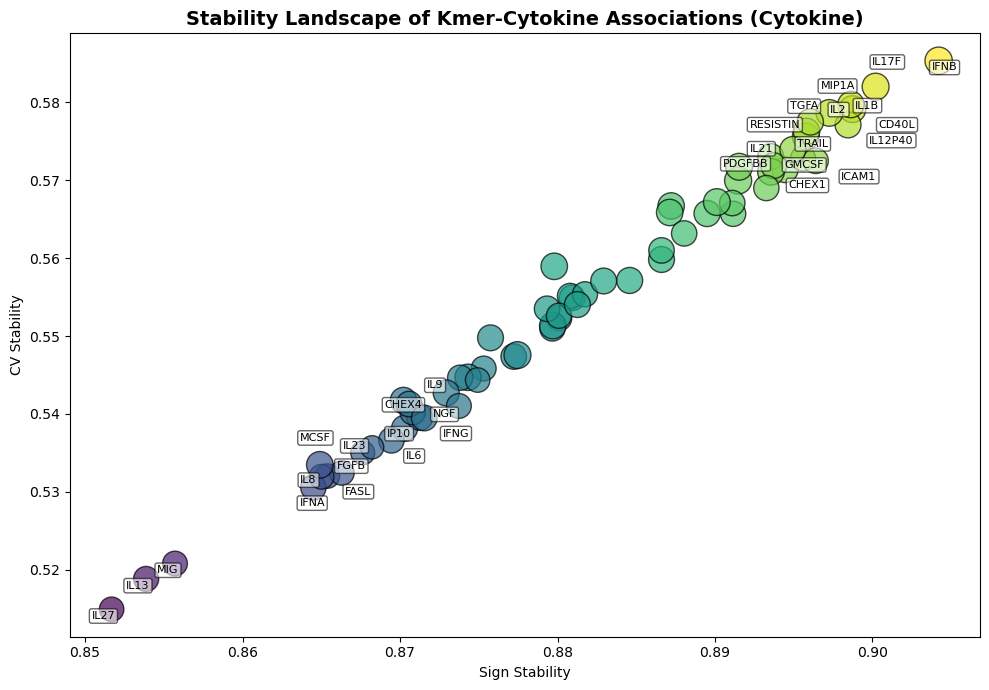

In [14]:
visualise_top_by_stability(resample_res, 'cyt', n=30)
plt.savefig('imgs/kmer_cytokine_association_cyt.png', dpi=400, bbox_inches='tight')

In [15]:
bins = [0, 0.2, 0.5, 0.7, 1.]
labels = ['V.Low', 'Low', 'Moderate', 'High']

heatmap_data = resample_res.pivot(index='kmer', columns='cyt', values='coef_mean').T
kmer_stability = pd.cut(resample_res.groupby('kmer').composite_score.mean(), bins=bins, labels=labels).astype(str)
cyt_stability = pd.cut(resample_res.groupby('cyt').composite_score.mean(), bins=bins, labels=labels).astype(str)

palette = dict(zip(labels, sns.color_palette("coolwarm", len(labels))))

cytokine_colors = None #cyt_stability.map(palette)
kmer_colors = None # kmer_stability.map(palette)

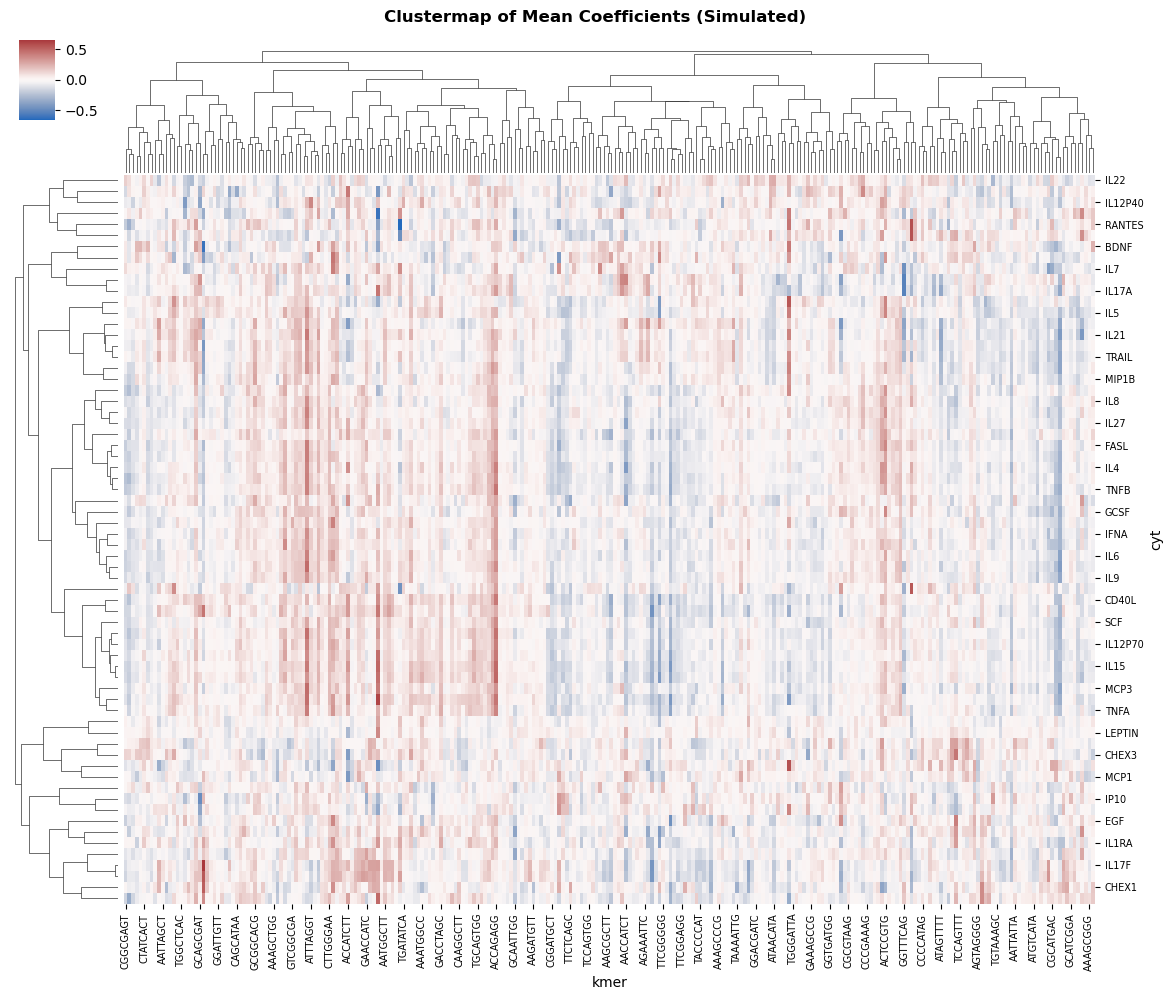

In [16]:
g = sns.clustermap(heatmap_data, metric='correlation', method='complete', figsize=(12,10),
               cmap='vlag', center=0, row_colors=cytokine_colors, col_colors=kmer_colors, 
               cbar_pos=(0.02, 0.91, 0.03, 0.08), dendrogram_ratio=(0.1, 0.15))
# Add legends for stability bars

# legend_elements = [Patch(facecolor=palette[label], label=label, linewidth=0.1) for label in labels]
# g.ax_heatmap.legend(handles=legend_elements, title='Composite Stability', loc='upper left',
#                     bbox_to_anchor=(1., 1.2), frameon=True)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)

# g.ax_row_colors.set_position([
#     g.ax_row_colors.get_position().x0,
#     g.ax_row_colors.get_position().y0,
#     g.ax_row_colors.get_position().width*0.2,
#     g.ax_row_colors.get_position().height  # Reduce height by 50%
# ])

# # Shrink column color bar width
# g.ax_col_colors.set_position([
#     g.ax_col_colors.get_position().x0,
#     g.ax_col_colors.get_position().y0,
#     g.ax_col_colors.get_position().width,  # Reduce width by 50%
#     g.ax_col_colors.get_position().height*0.5
# ])
plt.suptitle('Clustermap of Mean Coefficients (Simulated)', fontsize=12, fontweight='bold', y=1.02)
plt.savefig('imgs/clustermap_of_coef_scores.png', dpi=500, bbox_inches='tight')

__PCA__

__For Kmer__

In [17]:
xscaled = zscore(heatmap_data.T)

In [18]:
pca = PCA(2)
Xpca = pca.fit_transform(xscaled) # transpose to kmer x cyt

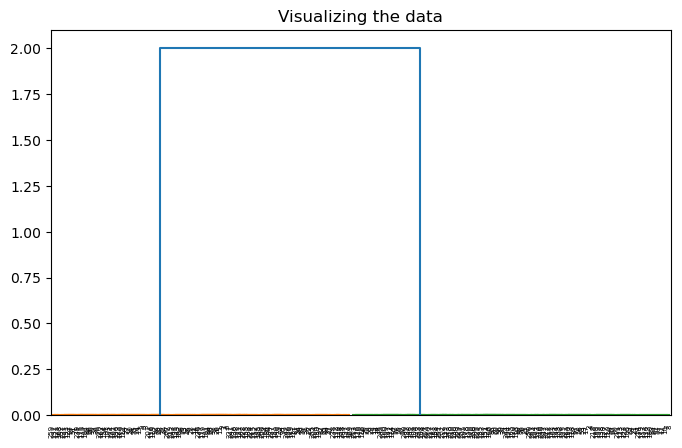

In [19]:
plt.figure(figsize=(8, 5))
plt.title('Visualizing the data')
dendrogram = shc.dendrogram(shc.linkage(Xpca, method='complete', metric='correlation'))
plt.show()

__Clustering__

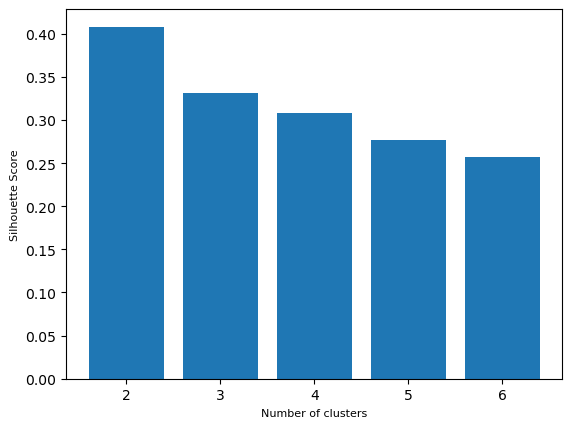

In [20]:
k = [2, 3, 4, 5, 6]
silhouette_scores = []
for i in k:
    ac = AgglomerativeClustering(n_clusters=i)
    labels = ac.fit_predict(Xpca)
    silhouette_scores.append(silhouette_score(Xpca, labels))

plt.bar(k, silhouette_scores)
plt.xlabel('Number of clusters', fontsize=8)
plt.ylabel('Silhouette Score', fontsize=8)
plt.show()

In [21]:
exp_var = pca.explained_variance_ratio_

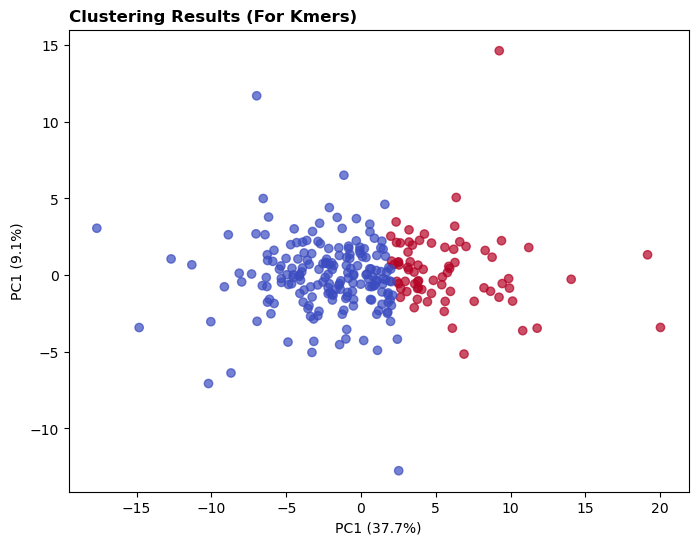

In [22]:
ac = AgglomerativeClustering(n_clusters=2)
plt.figure(figsize=(8, 6))
plt.scatter(Xpca[:, 0], Xpca[:, 1], c=ac.fit_predict(Xpca), cmap='coolwarm', alpha=0.7)
plt.title('Clustering Results (For Kmers)', loc='left', fontweight='bold', fontsize=12)
plt.xlabel(f'PC1 ({exp_var[0]:.1%})'); plt.ylabel(f'PC1 ({exp_var[1]:.1%})')
plt.savefig('imgs/clustering_res_kmer.png', dpi=300, bbox_inches='tight')
plt.show()

__For Cytokine__

In [23]:
xscaled = zscore(heatmap_data)

In [24]:
pca = PCA(2)
Xpca = pca.fit_transform(xscaled) # transpose to kmer x cyt

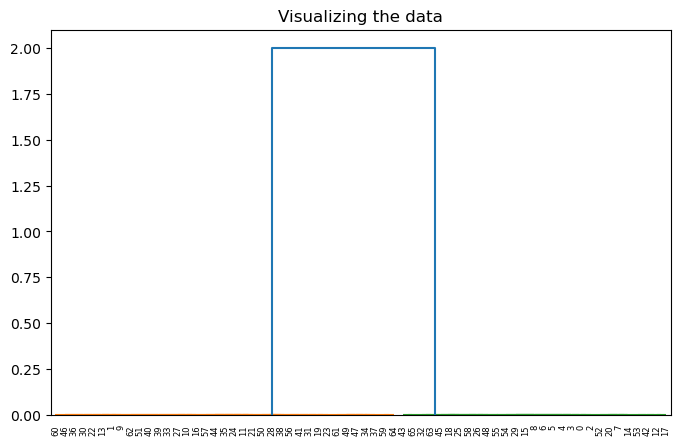

In [25]:
plt.figure(figsize=(8, 5))
plt.title('Visualizing the data')
dendrogram = shc.dendrogram(shc.linkage(Xpca, method='complete', metric='correlation'))
plt.show()

__Clustering__

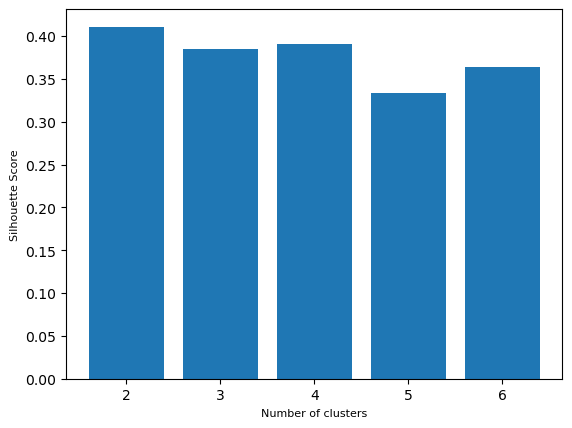

In [26]:
k = [2, 3, 4, 5, 6]
silhouette_scores = []
for i in k:
    ac = AgglomerativeClustering(n_clusters=i)
    labels = ac.fit_predict(Xpca)
    silhouette_scores.append(silhouette_score(Xpca, labels))

plt.bar(k, silhouette_scores)
plt.xlabel('Number of clusters', fontsize=8)
plt.ylabel('Silhouette Score', fontsize=8)
plt.show()

In [27]:
exp_var = pca.explained_variance_ratio_

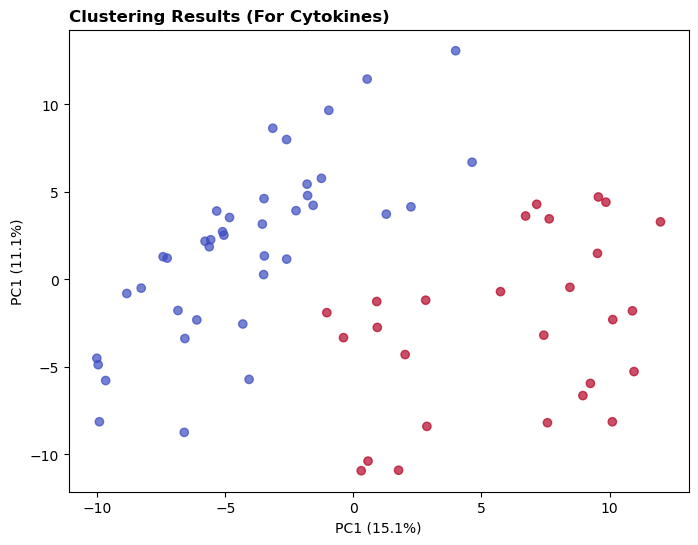

In [28]:
ac = AgglomerativeClustering(n_clusters=2)
plt.figure(figsize=(8, 6))
plt.scatter(Xpca[:, 0], Xpca[:, 1], c=ac.fit_predict(Xpca), cmap='coolwarm', alpha=0.7)
plt.title('Clustering Results (For Cytokines)', loc='left', fontweight='bold', fontsize=12)
plt.xlabel(f'PC1 ({exp_var[0]:.1%})'); plt.ylabel(f'PC1 ({exp_var[1]:.1%})')
plt.savefig('imgs/clustering_res_cyt.png', dpi=300, bbox_inches='tight')
plt.show()